# BaSSSh-seq — Bacterial scRNA-seq analysis
## Part 2: Leiden Clustering, Annotation & CellTypist

**Pipeline:**  
Load → UMAP/Leiden → Compositie → Markers → Annotatie → CellTypist → Trajectory

**Key parameters:**
- UMAP: `min_dist=0.24`, `spread=0.21`
- Leiden: `resolution=0.205` → 7 clusters
- Trajectory: Palantir, `n_components=5`, `num_waypoints=500`

## 6. Imports & settings
Same environment as Part 1. Run this cell first before anything else.

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import celltypist

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, frameon=False)

/home/nvanacker/miniconda3/envs/inab/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/nvanacker/miniconda3/envs/inab/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/nvanacker/miniconda3/envs/inab/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/nvanacker/miniconda3/envs/inab/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  warnings.warn(msg, FutureWarning)
/home/nvanacker/miniconda3/envs/inab/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarn

## 7. Load preprocessed data
Load the combined, HVG-filtered, BBKNN-corrected object produced at the end of Part 1.
Expected shape: **(7884 cells × 1015 HVGs)**. Cell names follow the `bf_X` / `p_X` convention.

In [9]:

adata_bacteria = sc.read_h5ad("../data/bacteria_all_genes_combined.h5ad")

# Sanity check
print(f"Cells : {adata_bacteria.n_obs}  (expected 7884)")
print(f"Genes : {adata_bacteria.n_vars} (expected 2853 HVGs)")
print(f"Columns in .obs : {adata_bacteria.obs.columns.tolist()}")
print(f"First 5 cell names: {adata_bacteria.obs_names[:5].tolist()}")
adata_bacteria.obs.head()

Cells : 7884  (expected 7884)
Genes : 2853 (expected 2853 HVGs)
Columns in .obs : ['total_counts', 'sample']
First 5 cell names: ['68', '96', '104', '107', '131']


,total_counts,sample
68,14.120000,bf
96,8.770000,bf
104,16.639999,bf
107,8.700000,bf
131,9.680000,bf


## 8. UMAP + Leiden clustering
Parameters taken directly from the paper Methods section: `min_dist=0.24`, `spread=0.21`, `resolution=0.205`.
The resolution was chosen to reproduce the 7 clusters reported in Fig. 2C.
If you obtain a different number, adjust resolution in small steps (±0.01) until 7 clusters appear.

/home/nvanacker/miniconda3/envs/inab/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Number of clusters found: 7 (Expected: 7)


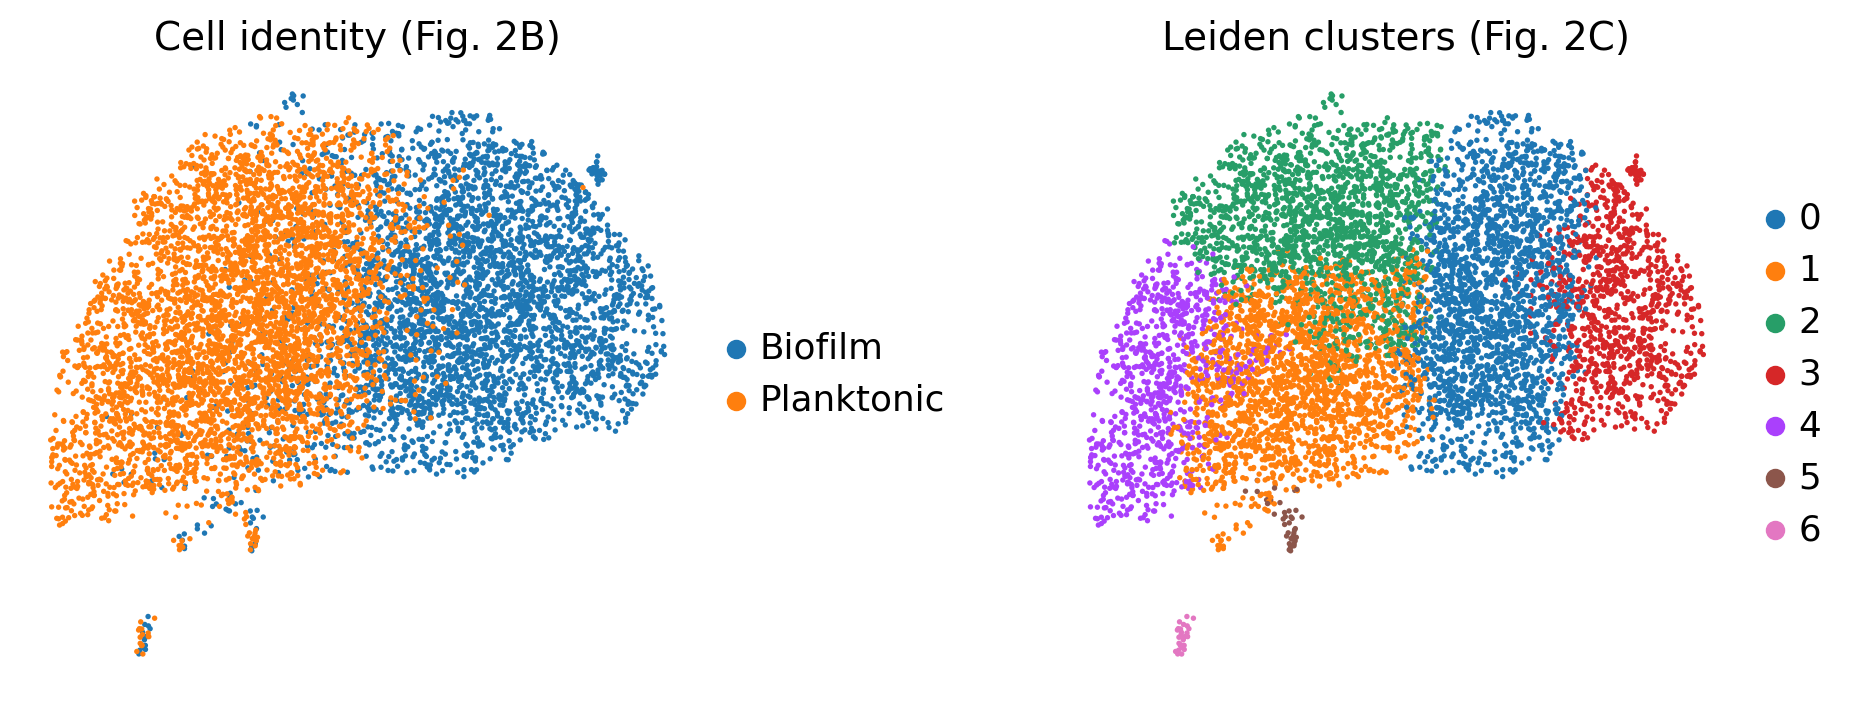

In [3]:
# 1. Compute UMAP (using parameters from the paper)
sc.tl.umap(adata_bacteria, min_dist=0.24, spread=0.21)

# 2. Run Leiden clustering
sc.tl.leiden(adata_bacteria, resolution=0.205)

n_clusters = adata_bacteria.obs['leiden'].nunique()
print(f"Number of clusters found: {n_clusters} (Expected: 7)")

# Create labels for visualization
label_map = {'bf': 'Biofilm', 'p': 'Planktonic'}
adata_bacteria.obs['Cell identity'] = adata_bacteria.obs['sample'].map(label_map)

# Plot the results
sc.pl.umap(
    adata_bacteria,
    color=['Cell identity', 'leiden'],
    title=['Cell identity (Fig. 2B)', 'Leiden clusters (Fig. 2C)'],
    wspace=0.4,
    frameon=False
)

## 9. Cluster composition (Fig. 2D)
Stacked bar chart showing the distribution of Biofilm (BF) vs Planktonic (P) cells per Leiden cluster.
Use this plot to guide annotation in Step 10:
- **>80% Planktonic** → likely a Planktonic subtype
- **>80% Biofilm** → likely a Biofilm subtype
- **~50/50** → Transitional state (Cluster 0 in the paper)

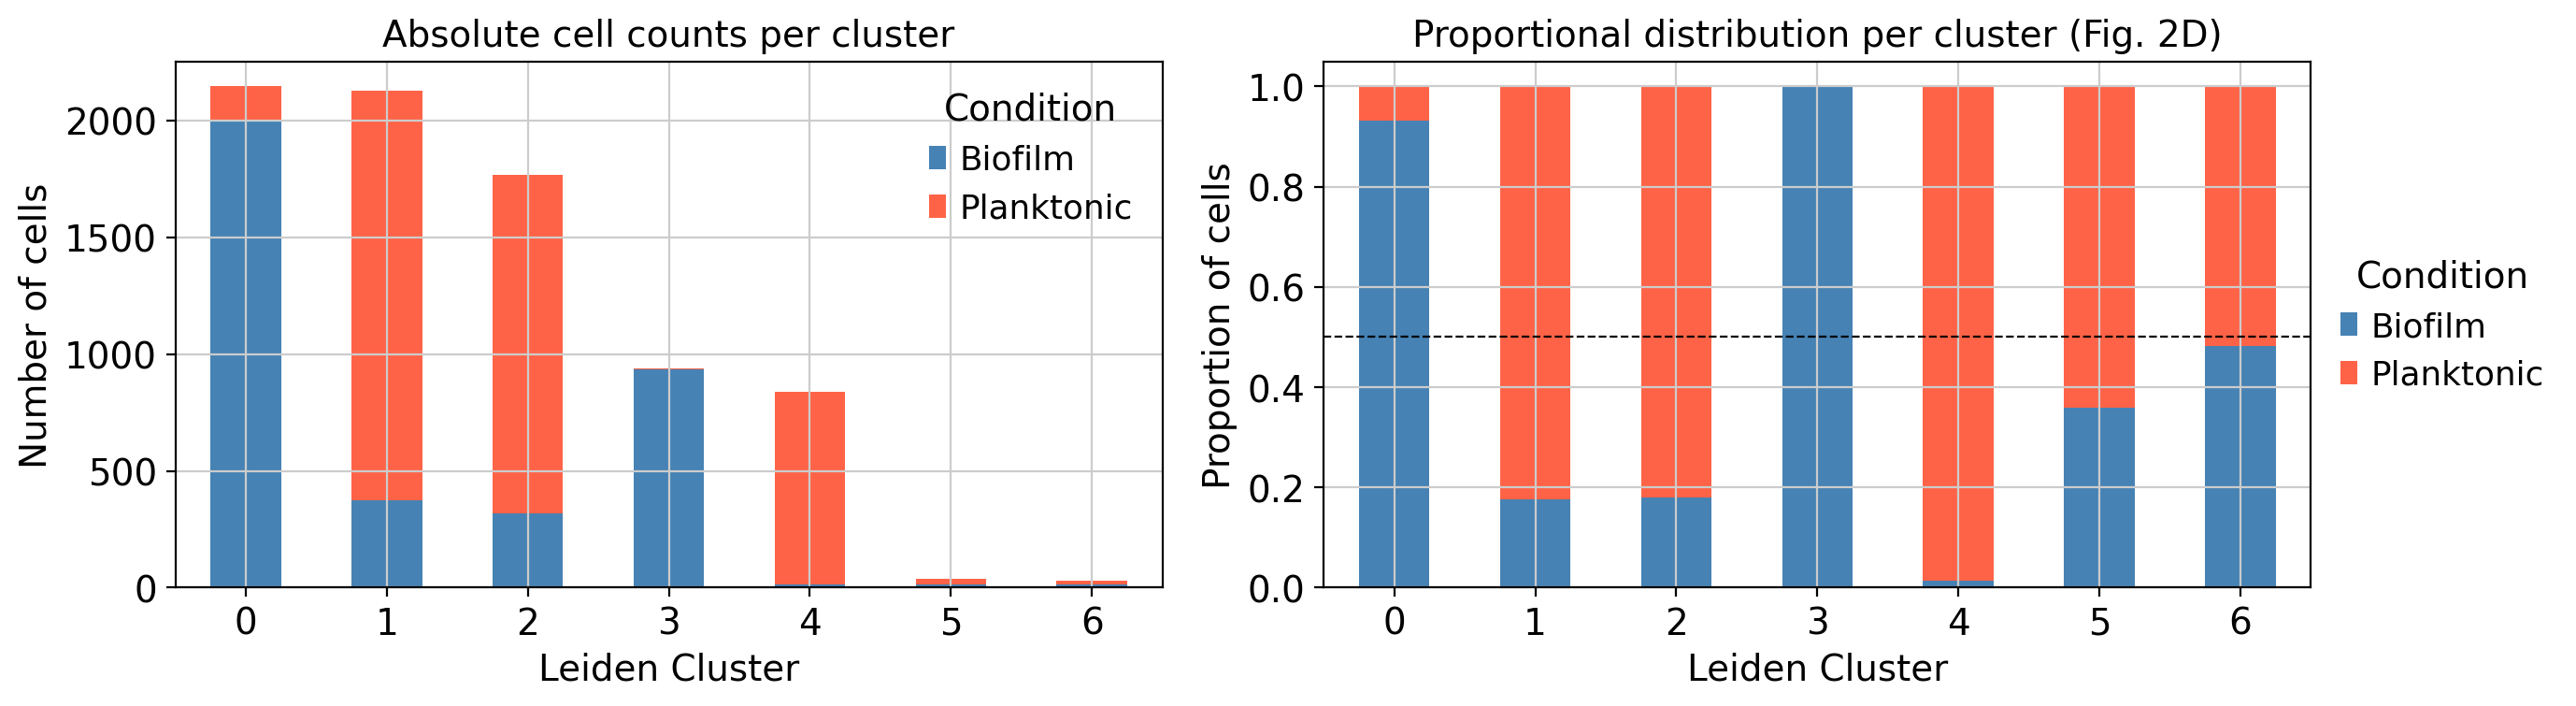

In [4]:
dist = pd.crosstab(adata_bacteria.obs['leiden'], adata_bacteria.obs['Cell identity'])
dist_norm = dist.div(dist.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
color_map = {'Biofilm': 'steelblue', 'Planktonic': 'tomato'}

# Absolute counts
dist.plot(kind='bar', ax=axes[0], color=color_map, stacked=True)
axes[0].set_ylabel('Number of cells')
axes[0].set_xlabel('Leiden Cluster')
axes[0].set_title('Absolute cell counts per cluster')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Condition', frameon=False)

# Normalised proportions (as in Fig. 2D paper)
dist_norm.plot(kind='bar', ax=axes[1], color=color_map, stacked=True)
axes[1].set_ylabel('Proportion of cells')
axes[1].set_xlabel('Leiden Cluster')
axes[1].set_title('Proportional distribution per cluster (Fig. 2D)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].axhline(0.5, color='black', linestyle='--', linewidth=0.8)
axes[1].legend(title='Condition', frameon=False, loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

## 10. Marker genes per cluster
The paper uses MAST (in R) for differential expression. Here we use **Wilcoxon rank-sum**, which is the standard Python/Scanpy equivalent and produces comparable results.

> **Note (explicitly stated in paper):** log2FC values in bacterial scRNA-seq are intentionally small and should not be interpreted as biologically insignificant.

The table below lists the expected marker genes from **Table 1 of the paper** for reference.

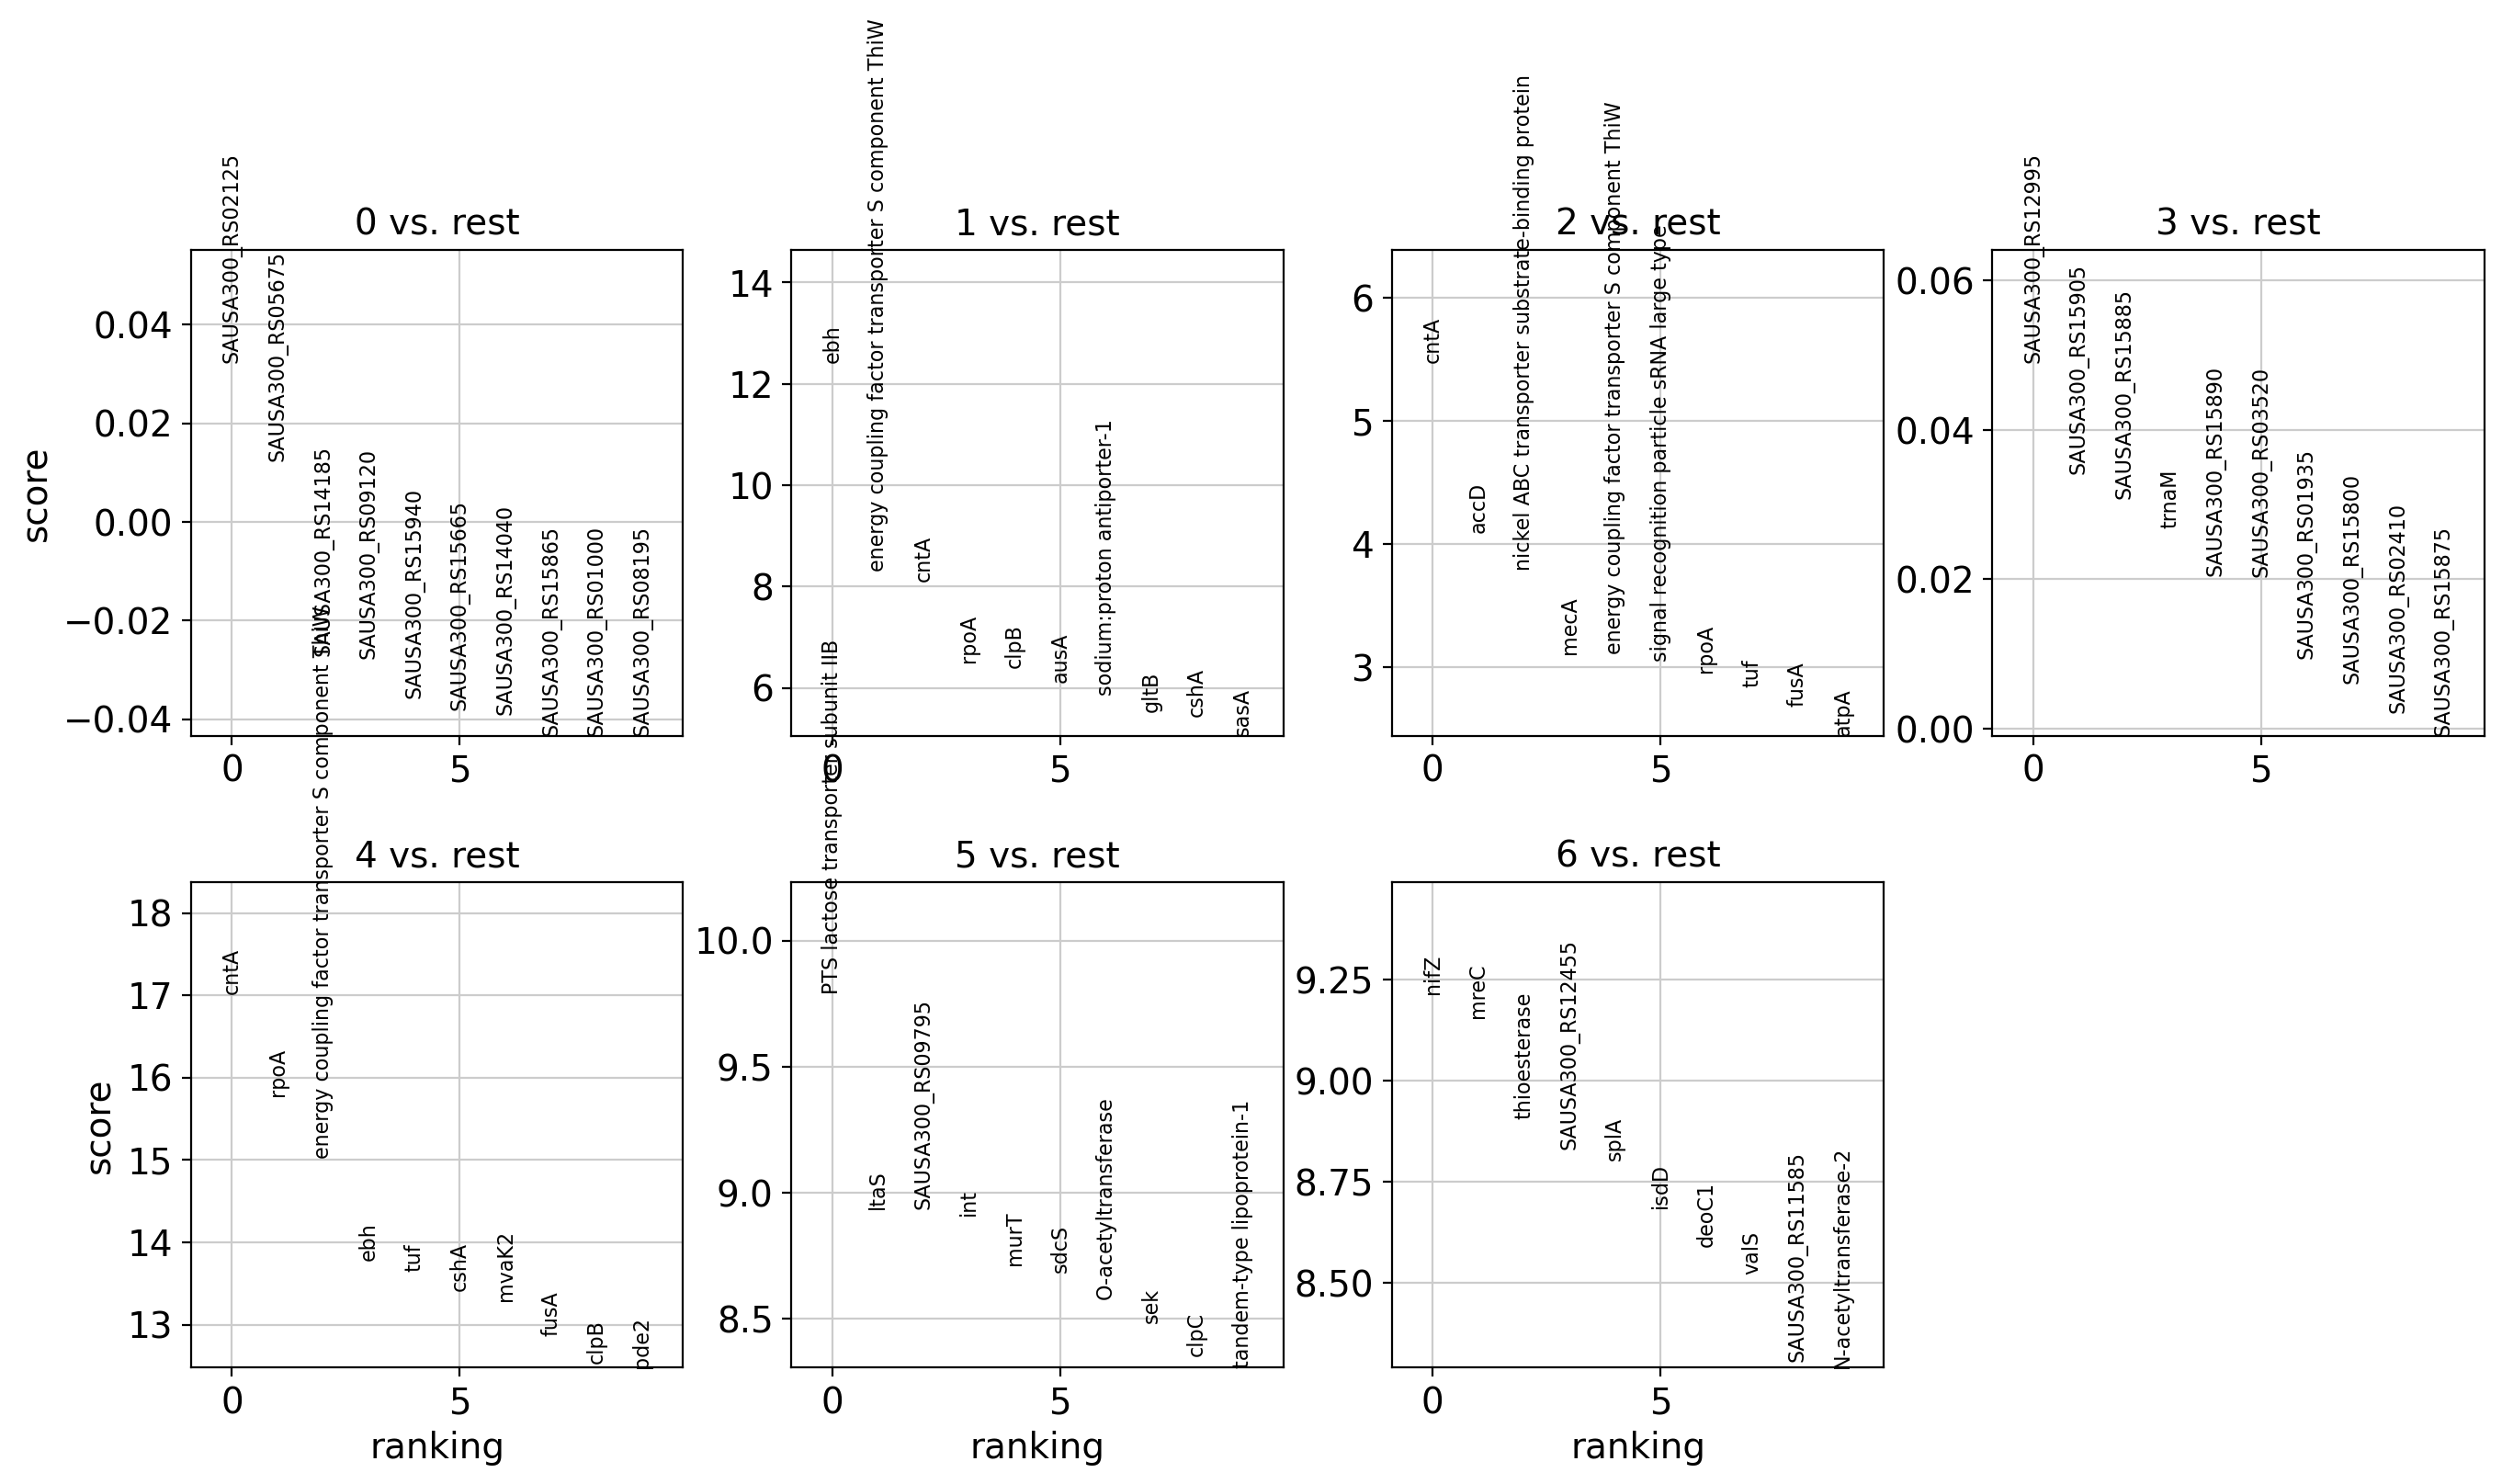

Top marker genes per cluster:
                  0                                                  1  \
0  SAUSA300_RS02125                                                ebh   
1  SAUSA300_RS05675  energy coupling factor transporter S component...   
2  SAUSA300_RS14185                                               cntA   
3  SAUSA300_RS09120                                               rpoA   
4  SAUSA300_RS15940                                               clpB   

                                                   2                 3  \
0                                               cntA  SAUSA300_RS12995   
1                                               accD  SAUSA300_RS15905   
2   nickel ABC transporter substrate-binding protein  SAUSA300_RS15885   
3                                               mecA             trnaM   
4  energy coupling factor transporter S component...  SAUSA300_RS15890   

                                                   4  \
0                       

In [5]:
sc.tl.rank_genes_groups(
    adata_bacteria,
    groupby='leiden',
    method='wilcoxon',  # best Python equivalent for MAST
    use_raw=True,       # use log-normalised counts before scaling
    pts=True            # include % of cells expressing each gene
)

# Top 10 markers per cluster (visual)
sc.pl.rank_genes_groups(adata_bacteria, n_genes=10, sharey=False)

# Top 5 table
marker_table = pd.DataFrame(adata_bacteria.uns['rank_genes_groups']['names']).head(5)
print("Top marker genes per cluster:")
print(marker_table)

# Expected markers from Table 1 of the paper (for comparison)
print("\n=== Expected markers (paper Table 1) ===")
paper_markers = {
    "Cluster 0 (Transitional)"      : ["sasA", "pnpA", "ebh"],
    "Cluster 1 (BF Active)"         : ["citB", "ltaS", "isdH", "ebpS"],
    "Cluster 2 (P Active)"          : ["rpoB", "rpsC", "ispA"],
    "Cluster 3 (BF Virulence)"      : ["clfB", "cspB", "arcA", "fnbB"],
    "Cluster 4 (P Stationary)"      : ["qoxA", "hemY", "rplY"],
    "Cluster 5 (BF Stress)"         : ["gpmA", "polX", "fdaB", "ureA"],
    "Cluster 6 (BF Replication)"    : ["nrdE"],
}
for cluster, genes in paper_markers.items():
    print(f"  {cluster}: {genes}")

print("\nCluster composition (% BF vs P):")
print(dist_norm.round(2))

## 11. Cluster annotation
Assign a biological label to each Leiden cluster based on:
1. The marker gene table above (Step 10)
2. The BF/P composition chart (Step 9)
3. Comparison with paper Table 1 markers

The names below reflect the paper's annotation. **Adjust if your marker genes or composition differ.**
Check `Unmapped cells` at the end — this must be 0 before training CellTypist.

Clusters in data:      ['0', '1', '2', '3', '4', '5', '6']
Clusters in name dict: ['0', '1', '2', '3', '4', '5', '6']

Unmapped cells: 0  ← must be 0


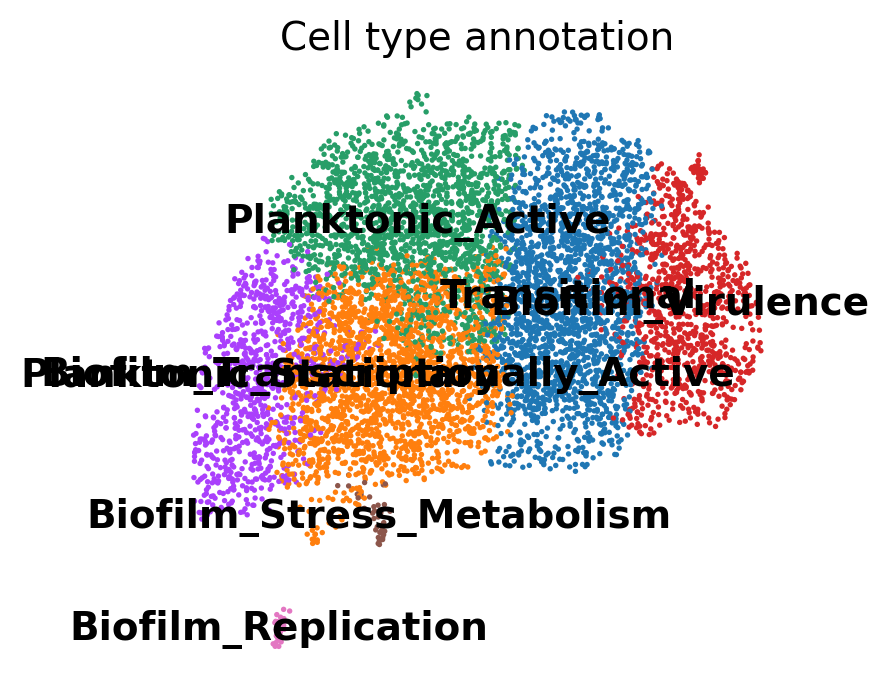

In [6]:
cluster_names = {
    '0': 'Transitional',                    # ~50/50 BF/P, sasA, pnpA
    '1': 'Biofilm_Transcriptionally_Active', # citB, ltaS, isdH
    '2': 'Planktonic_Active',               # rpoB, rpsC — most active
    '3': 'Biofilm_Virulence',               # clfB, fnbB, arcA
    '4': 'Planktonic_Stationary',           # qoxA, hemY
    '5': 'Biofilm_Stress_Metabolism',       # gpmA, polX, fdaB
    '6': 'Biofilm_Replication'              # nrdE
}

# Verify all clusters are covered
print(f"Clusters in data:      {sorted(adata_bacteria.obs['leiden'].unique())}")
print(f"Clusters in name dict: {sorted(cluster_names.keys())}")

adata_bacteria.obs['cell_type'] = adata_bacteria.obs['leiden'].map(cluster_names)
print(f"\nUnmapped cells: {adata_bacteria.obs['cell_type'].isna().sum()}  ← must be 0")

sc.pl.umap(
    adata_bacteria,
    color='cell_type',
    legend_loc='on data',
    title='Cell type annotation'
)

## 12. CellTypist model training
Train a CellTypist logistic regression classifier on the annotated clusters.
This model can then be used to automatically annotate new bacterial scRNA-seq datasets.

- `feature_selection=True`: selects the most informative genes (top 300)
- Output: `Staph_Aureus_BF_P_Model.pkl` — save this alongside the notebook

> **Prerequisite:** `Unmapped cells` in Step 11 must be 0. The `assert` below will catch this.

In [7]:
print(f"Cells without label: {adata_bacteria.obs['cell_type'].isna().sum()}")
assert adata_bacteria.obs['cell_type'].isna().sum() == 0, "Fix missing labels first!"

model = celltypist.train(
    adata_bacteria,
    labels='cell_type',
    feature_selection=True,
    top_genes=300
)

model.write('Staph_Aureus_BF_P_Model.pkl')
print("Model trained and saved as Staph_Aureus_BF_P_Model.pkl")
print(f"\nTop features: {model.features}")

🍳 Preparing data before training
👀 Detected scaled expression in the input data, will try the .raw attribute
🔬 Input data has 7884 cells and 2853 genes
⚖️ Scaling input data


Cells without label: 0


🏋️ Training data using SGD logistic regression
🔎 Selecting features
🧬 1423 features are selected
🏋️ Starting the second round of training
🏋️ Training data using logistic regression
✅ Model training done!


Model trained and saved as Staph_Aureus_BF_P_Model.pkl

Top features: ['dnaA' 'dnaN' 'RNA-binding protein' ... 'gidA' 'rnpA' 'rpmH']


In [10]:
import pickle 


'/mnt/c/Users/natha/OneDrive/Bio-informatica_25-26/International Internship/Internship-25-26/CellTypist_pipeline/notebooks'